# CAPRA on a measured Norman subset

This example uses the bundled measured data and GenePT embeddings. The public API handles condition splits, training, prediction, plotting, and checkpoint reload.

In [1]:
from pathlib import Path
import os
import sys
import warnings

cwd = Path.cwd().resolve()
repo_root = next((p for p in (cwd, *cwd.parents) if (p / "capra/frame.py").is_file()), None)
if repo_root is None:
    raise RuntimeError("Launch this notebook from the repository root or demo/.")
sys.path.insert(0, str(repo_root / "capra"))

import anndata as ad
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from frame import CAPRA, CAPRAData, load_gene_embedding_table

warnings.filterwarnings("ignore", category=pd.errors.PerformanceWarning,
                        message="DataFrame is highly fragmented.*")
torch.set_num_threads(min(4, os.cpu_count() or 1))


In [2]:
demo_name = "demo_norman_subset"
condition_key, perturbation_key = "condition", "perturbation"
seed, split_seed = 24, 1
n_pred, val_n_pred, num_workers = 16, 16, 0
accelerator = "gpu"
if not torch.cuda.is_available():
    raise RuntimeError("A CUDA GPU is required for this demo.")
output_dir = Path(os.environ.get("CAPRA_DEMO_OUTPUT_ROOT", str(repo_root / "demo/outputs"))) / demo_name
adata_path = repo_root / "demo/data/norman_example.h5ad"
embedding_path = repo_root / "demo/data/norman_example_genept_embeddings.pkl"
print("Input:", adata_path.name, "| GenePT:", embedding_path.name)


Input: norman_example.h5ad | GenePT: norman_example_genept_embeddings.pkl


## 1. Data setup

In [3]:
data = CAPRAData(study_name=demo_name, condition_key=condition_key,
                  perturbation_key=perturbation_key)
data.load_single_cell_adata(adata_path)
data.harmonize_perturbation_metadata(copy=False)
data.register_evaluation_partitions(split_strategy="auto", random_state=split_seed)

source = {key: list(data.splits[key]) for key in ("train", "val", "test")}
splits = {"train": source["train"][:40], "val": source["val"][:5], "test": source["test"][:6]}
labels = data.adata.obs["perturbation"].astype(str)
selected = []
for condition in ["control", *splits["train"], *splits["val"], *splits["test"]]:
    need = 128 if condition == "control" else 24
    cells = data.adata.obs_names[labels == condition]
    if len(cells) < need:
        raise ValueError(f"{condition}: only {len(cells)} cells")
    selected.extend(cells[:need])

adata = data.adata[selected].copy()
data = CAPRAData(adata=adata, study_name=demo_name,
                 condition_key=condition_key, perturbation_key=perturbation_key)
data.harmonize_perturbation_metadata(copy=False)
data.register_evaluation_partitions(split_dict=splits)
data.embedding_table = load_gene_embedding_table(embedding_path, add_control=True)
data.estimate_trainval_deg_reference(method="t-test")
data.build_control_relative_training_state()
print("AnnData:", data.adata.shape)
print("Splits:", {key: len(value) for key, value in data.splits.items()})


AnnData: (1352, 5025)
Splits: {'train': 40, 'val': 5, 'test': 6}


## 2. Train and predict

In [4]:
model = CAPRA(data)
model.fit_capra_response_operator(
    output_dir=output_dir / "results", run_name=f"{demo_name}_seed{seed}",
    n_epochs=2, min_epochs=1, seed=seed, accelerator=accelerator,
    precision="16-mixed", num_workers=num_workers, pin_memory=True,
    val_n_pred=val_n_pred,
)
test_conditions = list(data.splits["test"])[:3]
predictions = model.generate_counterfactual_profiles(
    pert_list=test_conditions, n_pred=n_pred,
)
print("Predicted:", {key: value.shape for key, value in predictions.items()})


CAPRA training | epoch 1/2 | train_loss=0.5362 | val_unseen_loss=0.2774 | monitor=0.3740 | patience=0/10


CAPRA training | epoch 2/2 | train_loss=0.5248 | val_unseen_loss=0.2727 | monitor=0.3610 | patience=0/10


Predicted: {'AHR+FEV': (16, 5025), 'ARRDC3': (16, 5025), 'BAK1': (16, 5025)}


## 3. Inspect the response

Held-out: AHR+FEV | Pearson r: 0.3525


,observed_delta,predicted_delta
gene_name,,
SH3BGRL3,1.5584,1.0598
FEV,1.5177,0.0741
HBG2,1.4407,-0.2295
CRYBA2,1.1582,-0.1474
HBG1,1.0904,0.0912
LAPTM5,0.8750,0.4015
TESC,0.8139,0.7357
KRT8,0.7704,0.4251
ODC1,-0.7609,-0.7665


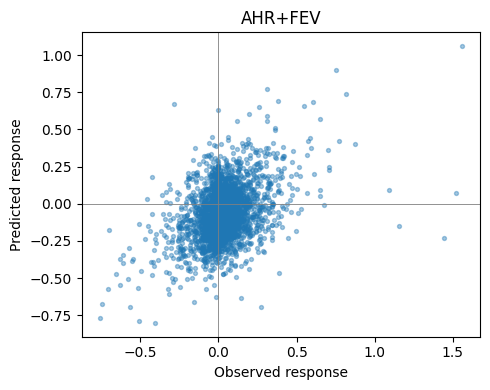

In [5]:
import matplotlib.pyplot as plt

condition = test_conditions[0]
labels = data.adata.obs["perturbation"].astype(str)
control_mean = np.asarray(data.adata[labels == "control"].X.mean(axis=0)).ravel()
observed_mean = np.asarray(data.adata[labels == condition].X.mean(axis=0)).ravel()
predicted_mean = predictions[condition].mean(axis=0)
response = pd.DataFrame({
    "observed_delta": observed_mean - control_mean,
    "predicted_delta": predicted_mean - control_mean,
}, index=data.adata.var_names)
pearson = np.corrcoef(response["observed_delta"], response["predicted_delta"])[0, 1]
print("Held-out:", condition, "| Pearson r:", round(float(pearson), 4))
display(response.loc[response["observed_delta"].abs().nlargest(10).index].round(4))
fig, ax = plt.subplots(figsize=(5, 4))
ax.scatter(response["observed_delta"], response["predicted_delta"], s=8, alpha=0.4)
ax.axhline(0, color="grey", linewidth=0.6)
ax.axvline(0, color="grey", linewidth=0.6)
ax.set(xlabel="Observed response", ylabel="Predicted response", title=condition)
fig.tight_layout()
plt.show()


## 4. Export and reload

In [6]:
blocks = []
for pert, matrix in predictions.items():
    assert matrix.shape == (n_pred, data.adata.n_vars)
    blocks.append(ad.AnnData(
        X=matrix.astype(np.float32),
        obs=pd.DataFrame({"condition": pert, "perturbation": pert},
                    index=[f"{pert}_{j:03d}" for j in range(n_pred)]),
        var=pd.DataFrame(index=data.adata.var_names),
    ))
prediction_adata = ad.concat(blocks, merge="same")
output_dir.mkdir(parents=True, exist_ok=True)
prediction_path = output_dir / "predictions.h5ad"
prediction_adata.write_h5ad(prediction_path)

checkpoint = model.fitted["metrics"]["best_checkpoint"]
loaded = CAPRA(data)
loaded.load_capra_response_operator(checkpoint, accelerator=accelerator,
                                    output_dir=output_dir / "results")
reloaded = loaded.generate_counterfactual_profiles(
    pert_list=[condition], n_pred=n_pred, sampling_state=seed,
)[condition]
np.testing.assert_allclose(reloaded, predictions[condition], rtol=1e-5, atol=1e-5)
print("Saved:", prediction_path)
print("Reload verified:", condition)


Saved: /home/fzc/projects/202604_CAPRA/tmp/githubload_review/compact_20261002/demo_norman_subset/predictions.h5ad
Reload verified: AHR+FEV
